Mempersiapkan Pipeline Preprocessing Data...

[INFO] Memuat Data Training:
Found 6633 images belonging to 2 classes.

[INFO] Memuat Data Testing:
Found 715 images belonging to 2 classes.

[INFO] Indeks Kelas yang Terdeteksi: {'def_front': 0, 'ok_front': 1}

Menampilkan Hasil Preprocessing & Augmentasi Data Training...
[SUKSES] Visualisasi sampel data tersimpan di: ../report_graphs/01_sample_data_training.png


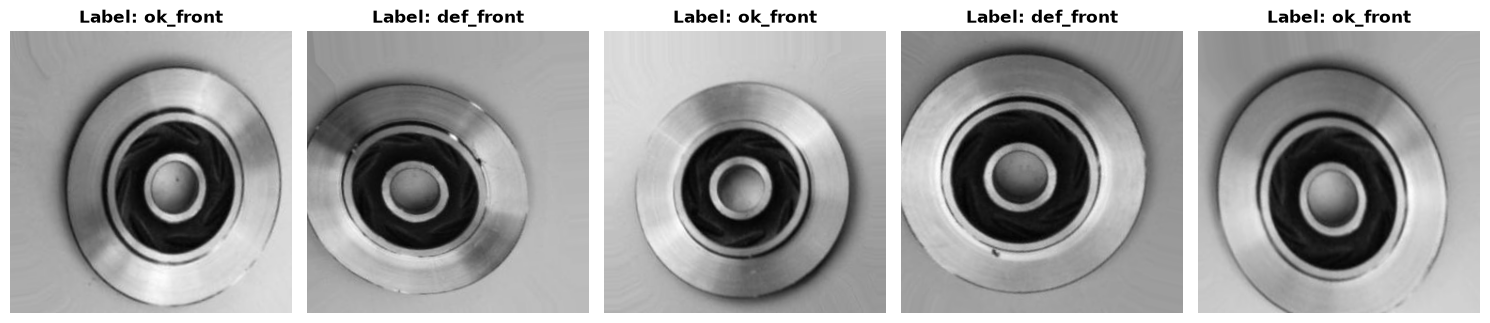

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Konfigurasi Direktori dan Parameter
# Memastikan folder output untuk grafik laporan tersedia
os.makedirs('../report_graphs', exist_ok=True)

# Menggunakan resolusi 300x300 agar konsisten dengan file evaluasi
IMG_WIDTH, IMG_HEIGHT = 300, 300
BATCH_SIZE = 32

TRAIN_DIR = '../dataset/casting_data/train/'
TEST_DIR = '../dataset/casting_data/test/'

print("Mempersiapkan Pipeline Preprocessing Data...")

# 2. Konfigurasi Augmentasi Data (Hanya untuk Training)
# Rescaling wajib untuk mengubah rentang piksel [0, 255] menjadi [0, 1]
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,       # Cacat pada logam bisa muncul dari sudut orientasi manapun
    width_shift_range=0.1,   # Toleransi jika posisi produk tidak tepat di tengah saat difoto
    height_shift_range=0.1,
    shear_range=0.1,         # Simulasi distorsi sudut lensa kamera pabrik
    zoom_range=0.1,          # Simulasi variasi jarak objek ke sensor kamera
    horizontal_flip=True,    # Bentuk casting umumnya simetris
    vertical_flip=True,
    fill_mode='nearest'      # Mengisi piksel kosong pasca-transformasi dengan piksel terdekat
)

# Data Uji (Testing) HARAM diaugmentasi secara spasial, cukup di-rescale saja
test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Inisialisasi Data Generator
print("\n[INFO] Memuat Data Training:")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Menggunakan categorical agar selaras dengan output model
    color_mode='rgb',
    shuffle=True              # Shuffle wajib True untuk training agar model tidak overfit pada urutan
)

print("\n[INFO] Memuat Data Testing:")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False             # Shuffle False sangat krusial untuk evaluasi metrik nantinya
)

# 4. Ekstraksi Pemetaan Kelas
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())
print(f"\n[INFO] Indeks Kelas yang Terdeteksi: {class_indices}")

# 5. Visualisasi Riset: Sampel Gambar Post-Augmentasi
def plot_sample_images(generator, class_names, filename_prefix="training"):
    """Fungsi untuk mengekstrak dan menyimpan visualisasi sampel data beresolusi tinggi"""
    images, labels = next(generator)
    plt.figure(figsize=(15, 6))
    
    # Menampilkan 5 sampel pertama dalam satu batch
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i])
        
        # Ekstraksi label dari format one-hot encoding (categorical)
        label_index = np.argmax(labels[i])
        plt.title(f"Label: {class_names[label_index]}", fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    
    # Menyimpan grafik untuk keperluan penulisan Laporan Ilmiah
    save_path = f'../report_graphs/01_sample_data_{filename_prefix}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"[SUKSES] Visualisasi sampel data tersimpan di: {save_path}")
    plt.show()

print("\nMenampilkan Hasil Preprocessing & Augmentasi Data Training...")
plot_sample_images(train_generator, class_names, "training")